In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score

os.makedirs('images', exist_ok=True)

In [3]:
df = pd.read_csv('dataset/Dataset.csv')

print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (1000, 13)


,Math,Physics,Chemistry,Biology,Total_Science,Average_Science,English,Computer_Science,Sports_Score,Attendance_Percentage,Random_Noise_Feature,Final_Score_Regression,Performance_Level_Classification
0,81.963919,71.591250,65.428104,69.786180,288.769453,71.344844,63.564348,80.470009,59.504621,88.827011,-33.924737,63.165168,Medium
1,73.240525,67.894764,64.315432,68.430136,273.880857,67.563386,62.984703,57.450119,52.445246,90.367064,-15.274973,65.503878,Medium
2,76.775037,72.514786,74.408858,76.584987,300.283667,71.479630,65.997338,81.184728,57.414376,87.493450,-29.869053,75.776067,High
3,81.995615,83.690491,94.668737,88.066081,348.420923,86.445050,75.277242,81.548170,70.720976,75.287512,5.520902,83.577602,High
4,71.149583,58.190393,70.441232,59.457316,259.238524,66.275289,65.647724,74.078977,79.167850,84.222888,59.858927,69.100684,Medium


In [4]:
print('Missing Values per Column:')
print(df.isnull().sum())
print()
print('Data Types:')
print(df.dtypes)

Missing Values per Column:
Math                                0
Physics                             0
Chemistry                           0
Biology                             0
Total_Science                       0
Average_Science                     0
English                             0
Computer_Science                    0
Sports_Score                        0
Attendance_Percentage               0
Random_Noise_Feature                0
Final_Score_Regression              0
Performance_Level_Classification    0
dtype: int64

Data Types:
Math                                float64
Physics                             float64
Chemistry                           float64
Biology                             float64
Total_Science                       float64
Average_Science                     float64
English                             float64
Computer_Science                    float64
Sports_Score                        float64
Attendance_Percentage               float64
Random_Noise_

In [6]:
# Handle missing values
df.dropna(inplace=True)

# Separate targets
reg_target = 'Final_Score_Regression'
clf_target = 'Performance_Level_Classification'

# Encode classification target
le = LabelEncoder()
df[clf_target + '_enc'] = le.fit_transform(df[clf_target])

print('Classification target classes:', le.classes_)
print('Target distribution (Classification):')
print(df[clf_target].value_counts())

Classification target classes: ['High' 'Low' 'Medium']
Target distribution (Classification):
Performance_Level_Classification
Medium    545
Low       253
High      202
Name: count, dtype: int64


In [7]:
# Build feature matrix (drop both target columns)
drop_cols = [reg_target, clf_target, clf_target + '_enc']
X = df.drop(columns=drop_cols)

y_reg = df[reg_target].values
y_clf = df[clf_target + '_enc'].values

print('Feature Matrix Shape:', X.shape)
print('Regression Target Shape:', y_reg.shape)
print('Classification Target Shape:', y_clf.shape)

Feature Matrix Shape: (1000, 11)
Regression Target Shape: (1000,)
Classification Target Shape: (1000,)


In [8]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Standardized feature matrix shape:', X_scaled.shape)

Standardized feature matrix shape: (1000, 11)


In [9]:
# Fit PCA on entire scaled data to determine n_components (95% variance)
pca_full = PCA(n_components=0.95, random_state=42)
pca_full.fit(X_scaled)

n_components = pca_full.n_components_
total_variance = np.sum(pca_full.explained_variance_ratio_) * 100

print(f'Components chosen to retain 95% variance: {n_components}')
print(f'Actual explained variance: {total_variance:.2f}%')

Components chosen to retain 95% variance: 7
Actual explained variance: 95.90%


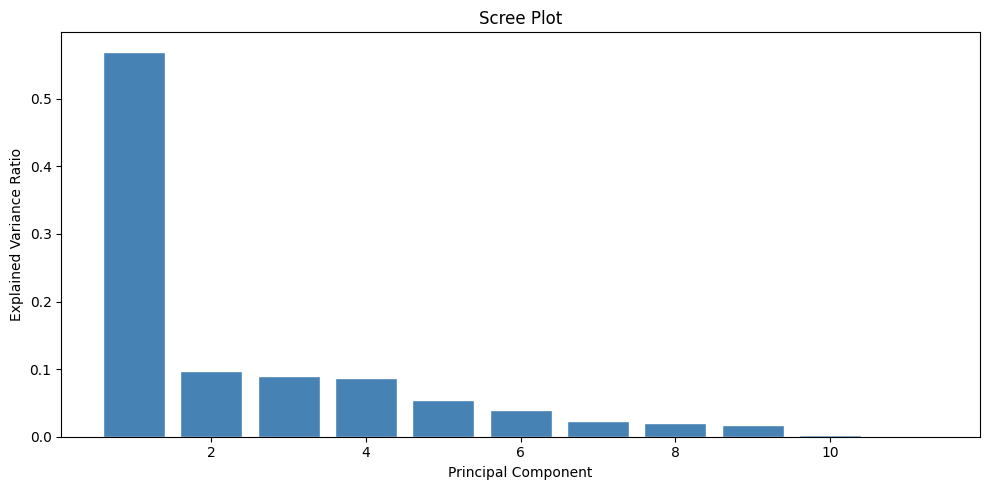

In [10]:
# Scree Plot
pca_all = PCA(random_state=42)
pca_all.fit(X_scaled)

plt.figure(figsize=(10, 5))
plt.bar(
    range(1, len(pca_all.explained_variance_ratio_) + 1),
    pca_all.explained_variance_ratio_,
    color='steelblue', edgecolor='white'
)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.tight_layout()
plt.savefig('images/scree_plot.png', dpi=300)
plt.show()

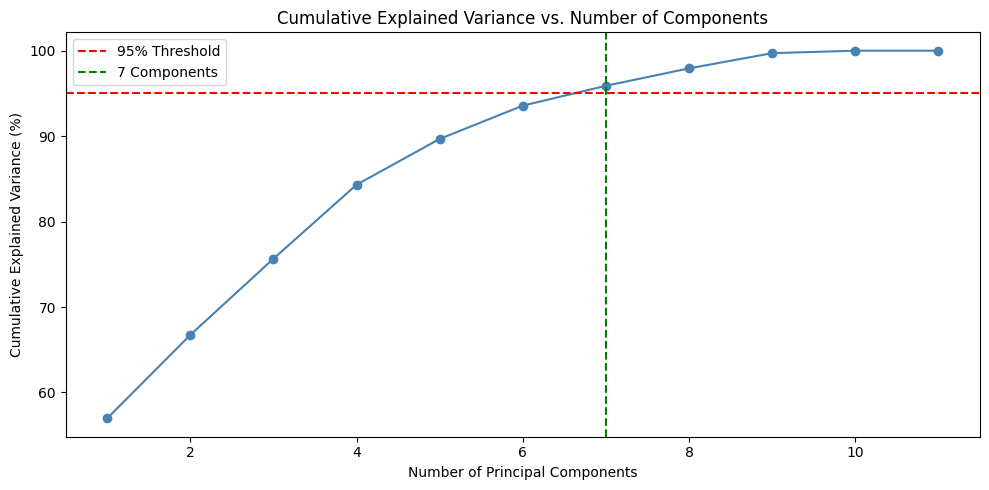

In [11]:
# Cumulative Explained Variance Plot
cumulative_var = np.cumsum(pca_all.explained_variance_ratio_) * 100

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o', color='steelblue')
plt.axhline(y=95, color='red', linestyle='--', label='95% Threshold')
plt.axvline(x=n_components, color='green', linestyle='--', label=f'{n_components} Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Cumulative Explained Variance vs. Number of Components')
plt.legend()
plt.tight_layout()
plt.savefig('images/cumulative_variance.png', dpi=300)
plt.show()

In [12]:
# -------------------------------------------------------
# Helper: 5-Fold CV for Regression (with & without PCA)
# -------------------------------------------------------
def cv_regression(model, X_data, y_data, use_pca=False, n_comp=None):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    mse_scores, r2_scores = [], []

    for train_idx, test_idx in kf.split(X_data):
        X_tr, X_te = X_data[train_idx], X_data[test_idx]
        y_tr, y_te = y_data[train_idx], y_data[test_idx]

        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        if use_pca:
            pca = PCA(n_components=n_comp, random_state=42)
            X_tr = pca.fit_transform(X_tr)
            X_te = pca.transform(X_te)

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        mse_scores.append(mean_squared_error(y_te, y_pred))
        r2_scores.append(r2_score(y_te, y_pred))

    return np.mean(mse_scores), np.mean(r2_scores)


# -------------------------------------------------------
# Helper: 5-Fold CV for Classification (with & without PCA)
# -------------------------------------------------------
def cv_classification(model, X_data, y_data, use_pca=False, n_comp=None):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    acc_scores, f1_scores = [], []

    for train_idx, test_idx in kf.split(X_data):
        X_tr, X_te = X_data[train_idx], X_data[test_idx]
        y_tr, y_te = y_data[train_idx], y_data[test_idx]

        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)

        if use_pca:
            pca = PCA(n_components=n_comp, random_state=42)
            X_tr = pca.fit_transform(X_tr)
            X_te = pca.transform(X_te)

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        acc_scores.append(accuracy_score(y_te, y_pred))
        f1_scores.append(f1_score(y_te, y_pred, average='weighted'))

    return np.mean(acc_scores), np.mean(f1_scores)


X_np = X.values
print('Helper functions defined.')

Helper functions defined.


In [13]:
# -------------------------------------------------------
# Regression: Linear Regression
# -------------------------------------------------------
lr_mse_no, lr_r2_no   = cv_regression(LinearRegression(), X_np, y_reg, use_pca=False)
lr_mse_pca, lr_r2_pca = cv_regression(LinearRegression(), X_np, y_reg, use_pca=True, n_comp=n_components)

print('Linear Regression (No PCA)  -- MSE: {:.4f}  R2: {:.4f}'.format(lr_mse_no, lr_r2_no))
print('Linear Regression (PCA)     -- MSE: {:.4f}  R2: {:.4f}'.format(lr_mse_pca, lr_r2_pca))

Linear Regression (No PCA)  -- MSE: 26.2338  R2: 0.7479
Linear Regression (PCA)     -- MSE: 26.2766  R2: 0.7476


In [14]:
# -------------------------------------------------------
# Regression: Random Forest (with hyperparameter tuning)
# -------------------------------------------------------
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring='r2'
)

rf_grid.fit(X_scaled, y_reg)
print('Best RF Regressor Params:', rf_grid.best_params_)

best_rf_reg = RandomForestRegressor(**rf_grid.best_params_, random_state=42)

rf_mse_no, rf_r2_no   = cv_regression(best_rf_reg, X_np, y_reg, use_pca=False)
rf_mse_pca, rf_r2_pca = cv_regression(best_rf_reg, X_np, y_reg, use_pca=True, n_comp=n_components)

print('Random Forest (No PCA)  -- MSE: {:.4f}  R2: {:.4f}'.format(rf_mse_no, rf_r2_no))
print('Random Forest (PCA)     -- MSE: {:.4f}  R2: {:.4f}'.format(rf_mse_pca, rf_r2_pca))

Best RF Regressor Params: {'max_depth': 5, 'n_estimators': 200}
Random Forest (No PCA)  -- MSE: 28.7219  R2: 0.7241
Random Forest (PCA)     -- MSE: 27.8283  R2: 0.7328


In [15]:
# Regression Results Table
reg_results = pd.DataFrame({
    'Model':    ['Linear Regression', 'Linear Regression', 'Random Forest', 'Random Forest'],
    'Metric':   ['MSE', 'R2', 'MSE', 'R2'],
    'No PCA':   [lr_mse_no, lr_r2_no, rf_mse_no, rf_r2_no],
    'With PCA': [lr_mse_pca, lr_r2_pca, rf_mse_pca, rf_r2_pca]
})

print('Regression 5-Fold CV Results:')
print(reg_results.to_string(index=False))

Regression 5-Fold CV Results:
            Model Metric    No PCA  With PCA
Linear Regression    MSE 26.233840 26.276612
Linear Regression     R2  0.747895  0.747591
    Random Forest    MSE 28.721853 27.828273
    Random Forest     R2  0.724139  0.732770


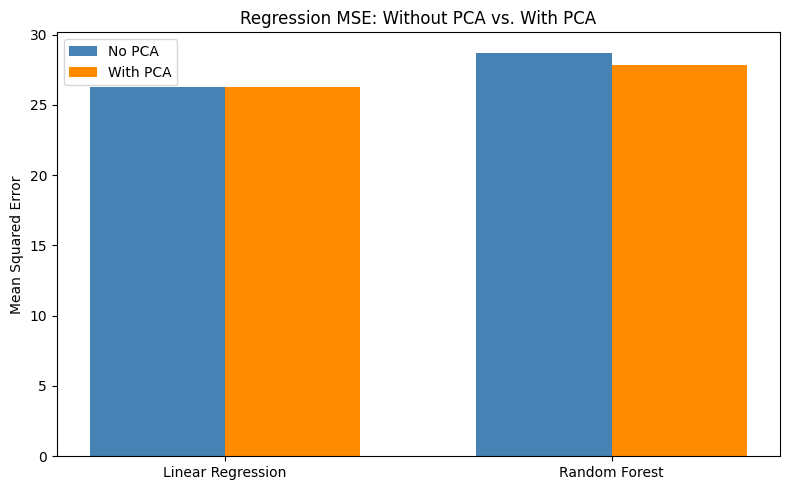

In [16]:
# Regression Bar Chart: MSE
models = ['Linear Regression', 'Random Forest']
mse_no  = [lr_mse_no,  rf_mse_no]
mse_pca = [lr_mse_pca, rf_mse_pca]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, mse_no,  width, label='No PCA',   color='steelblue')
plt.bar(x + width/2, mse_pca, width, label='With PCA', color='darkorange')
plt.xticks(x, models)
plt.ylabel('Mean Squared Error')
plt.title('Regression MSE: Without PCA vs. With PCA')
plt.legend()
plt.tight_layout()
plt.savefig('images/reg_mse_comparison.png', dpi=300)
plt.show()

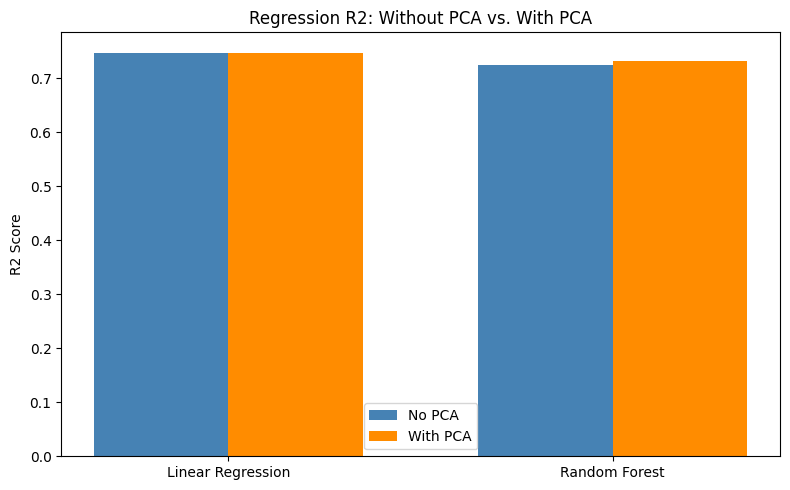

In [17]:
# Regression Bar Chart: R2
r2_no  = [lr_r2_no,  rf_r2_no]
r2_pca = [lr_r2_pca, rf_r2_pca]

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, r2_no,  width, label='No PCA',   color='steelblue')
plt.bar(x + width/2, r2_pca, width, label='With PCA', color='darkorange')
plt.xticks(x, models)
plt.ylabel('R2 Score')
plt.title('Regression R2: Without PCA vs. With PCA')
plt.legend()
plt.tight_layout()
plt.savefig('images/reg_r2_comparison.png', dpi=300)
plt.show()

In [18]:
# -------------------------------------------------------
# Classification: Logistic Regression (with C tuning)
# -------------------------------------------------------
log_params = {'C': [0.01, 0.1, 1, 10]}

log_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    log_params,
    cv=5,
    scoring='accuracy'
)

log_grid.fit(X_scaled, y_clf)
print('Best Logistic Regression Params:', log_grid.best_params_)

best_lr_clf = LogisticRegression(C=log_grid.best_params_['C'], max_iter=1000, random_state=42)

log_acc_no, log_f1_no   = cv_classification(best_lr_clf, X_np, y_clf, use_pca=False)
log_acc_pca, log_f1_pca = cv_classification(best_lr_clf, X_np, y_clf, use_pca=True, n_comp=n_components)

print('Logistic Regression (No PCA)  -- Acc: {:.4f}  F1: {:.4f}'.format(log_acc_no, log_f1_no))
print('Logistic Regression (PCA)     -- Acc: {:.4f}  F1: {:.4f}'.format(log_acc_pca, log_f1_pca))

Best Logistic Regression Params: {'C': 0.1}
Logistic Regression (No PCA)  -- Acc: 0.7380  F1: 0.7350
Logistic Regression (PCA)     -- Acc: 0.7440  F1: 0.7411


In [19]:
# -------------------------------------------------------
# Classification: SVM (with kernel / C / gamma tuning)
# -------------------------------------------------------
svm_params = {
    'kernel': ['linear', 'rbf'],
    'C':      [0.1, 1, 10],
    'gamma':  ['scale', 'auto']
}

svm_grid = GridSearchCV(
    SVC(random_state=42),
    svm_params,
    cv=5,
    scoring='accuracy'
)

svm_grid.fit(X_scaled, y_clf)
print('Best SVM Params:', svm_grid.best_params_)

best_svm = SVC(**svm_grid.best_params_, random_state=42)

svm_acc_no, svm_f1_no   = cv_classification(best_svm, X_np, y_clf, use_pca=False)
svm_acc_pca, svm_f1_pca = cv_classification(best_svm, X_np, y_clf, use_pca=True, n_comp=n_components)

print('SVM (No PCA)  -- Acc: {:.4f}  F1: {:.4f}'.format(svm_acc_no, svm_f1_no))
print('SVM (PCA)     -- Acc: {:.4f}  F1: {:.4f}'.format(svm_acc_pca, svm_f1_pca))

Best SVM Params: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
SVM (No PCA)  -- Acc: 0.7420  F1: 0.7354
SVM (PCA)     -- Acc: 0.7320  F1: 0.7251


In [20]:
# Classification Results Table
clf_results = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Logistic Regression', 'SVM', 'SVM'],
    'Metric':   ['Accuracy', 'F1-score', 'Accuracy', 'F1-score'],
    'No PCA':   [log_acc_no, log_f1_no, svm_acc_no, svm_f1_no],
    'With PCA': [log_acc_pca, log_f1_pca, svm_acc_pca, svm_f1_pca]
})

print('Classification 5-Fold CV Results:')
print(clf_results.to_string(index=False))

Classification 5-Fold CV Results:
              Model   Metric   No PCA  With PCA
Logistic Regression Accuracy 0.738000  0.744000
Logistic Regression F1-score 0.735009  0.741113
                SVM Accuracy 0.742000  0.732000
                SVM F1-score 0.735375  0.725071


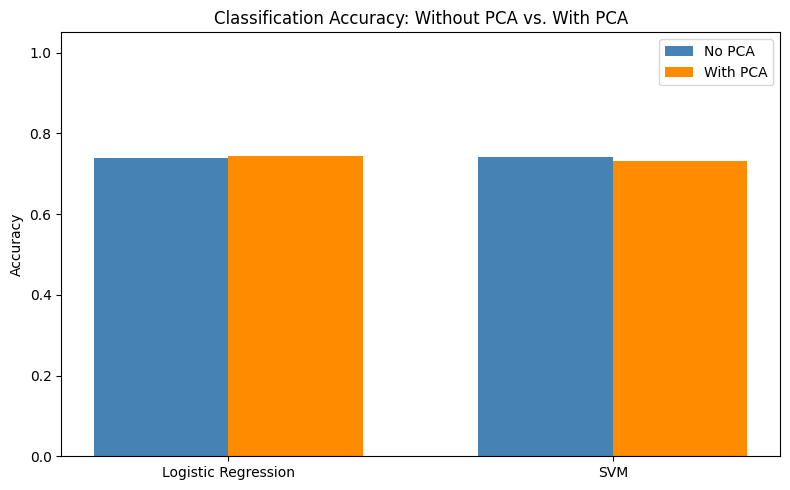

In [21]:
# Classification Bar Chart: Accuracy
clf_models = ['Logistic Regression', 'SVM']
acc_no  = [log_acc_no,  svm_acc_no]
acc_pca = [log_acc_pca, svm_acc_pca]

x2 = np.arange(len(clf_models))

plt.figure(figsize=(8, 5))
plt.bar(x2 - width/2, acc_no,  width, label='No PCA',   color='steelblue')
plt.bar(x2 + width/2, acc_pca, width, label='With PCA', color='darkorange')
plt.xticks(x2, clf_models)
plt.ylabel('Accuracy')
plt.title('Classification Accuracy: Without PCA vs. With PCA')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig('images/clf_acc_comparison.png', dpi=300)
plt.show()

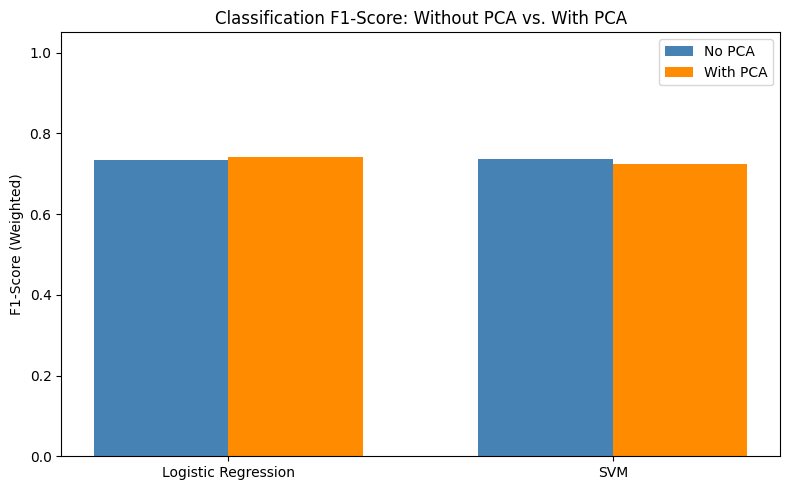

In [22]:
# Classification Bar Chart: F1-Score
f1_no  = [log_f1_no,  svm_f1_no]
f1_pca = [log_f1_pca, svm_f1_pca]

plt.figure(figsize=(8, 5))
plt.bar(x2 - width/2, f1_no,  width, label='No PCA',   color='steelblue')
plt.bar(x2 + width/2, f1_pca, width, label='With PCA', color='darkorange')
plt.xticks(x2, clf_models)
plt.ylabel('F1-Score (Weighted)')
plt.title('Classification F1-Score: Without PCA vs. With PCA')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig('images/clf_f1_comparison.png', dpi=300)
plt.show()

In [23]:
# Full Summary
print('=' * 65)
print('               EXPERIMENT 8 - FULL SUMMARY')
print('=' * 65)
print(f'PCA Components Chosen : {n_components}')
print(f'Explained Variance    : {total_variance:.2f}%')
print()
print('--- REGRESSION (5-Fold CV Averages) ---')
print(f'  Linear Regression  No PCA  | MSE: {lr_mse_no:.4f}  R2: {lr_r2_no:.4f}')
print(f'  Linear Regression  PCA     | MSE: {lr_mse_pca:.4f}  R2: {lr_r2_pca:.4f}')
print(f'  Random Forest      No PCA  | MSE: {rf_mse_no:.4f}  R2: {rf_r2_no:.4f}')
print(f'  Random Forest      PCA     | MSE: {rf_mse_pca:.4f}  R2: {rf_r2_pca:.4f}')
print()
print('--- CLASSIFICATION (5-Fold CV Averages) ---')
print(f'  Logistic Regression  No PCA  | Acc: {log_acc_no:.4f}  F1: {log_f1_no:.4f}')
print(f'  Logistic Regression  PCA     | Acc: {log_acc_pca:.4f}  F1: {log_f1_pca:.4f}')
print(f'  SVM                  No PCA  | Acc: {svm_acc_no:.4f}  F1: {svm_f1_no:.4f}')
print(f'  SVM                  PCA     | Acc: {svm_acc_pca:.4f}  F1: {svm_f1_pca:.4f}')
print('=' * 65)

               EXPERIMENT 8 - FULL SUMMARY
PCA Components Chosen : 7
Explained Variance    : 95.90%

--- REGRESSION (5-Fold CV Averages) ---
  Linear Regression  No PCA  | MSE: 26.2338  R2: 0.7479
  Linear Regression  PCA     | MSE: 26.2766  R2: 0.7476
  Random Forest      No PCA  | MSE: 28.7219  R2: 0.7241
  Random Forest      PCA     | MSE: 27.8283  R2: 0.7328

--- CLASSIFICATION (5-Fold CV Averages) ---
  Logistic Regression  No PCA  | Acc: 0.7380  F1: 0.7350
  Logistic Regression  PCA     | Acc: 0.7440  F1: 0.7411
  SVM                  No PCA  | Acc: 0.7420  F1: 0.7354
  SVM                  PCA     | Acc: 0.7320  F1: 0.7251
